# 1. Launch a new python notebook and read the data set. EDA & Pre-processing (Make sure to remove all non-numeric entries from numeric columns) – 5 points


In [59]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm


In [23]:
# Read the dataset
cars_mpg_df = pd.read_csv("cars-dataset.csv")  
cars_mpg_df.head()

,car name,cyl,disp,hp,wt,acc,yr,mpg
0,chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0
1,buick skylark 320,8,350.0,165,3693,11.5,70,15.0
2,plymouth satellite,8,318.0,150,3436,11.0,70,18.0
3,amc rebel sst,8,304.0,150,3433,12.0,70,16.0
4,ford torino,8,302.0,140,3449,10.5,70,17.0


In [24]:
cars_mpg_df.describe().T


,count,mean,std,min,25%,50%,75%,max
cyl,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
disp,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
wt,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acc,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
yr,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6


In [25]:
duplicateRowsDF = cars_mpg_df[cars_mpg_df.duplicated(['car name'])]
 
print("Duplicate Rows based on a single column are:", duplicateRowsDF, sep='\n')

Duplicate Rows based on a single column are:
                              car name  cyl   disp   hp    wt   acc  yr   mpg
29                        datsun pl510    4   97.0   88  2130  14.5  71  27.0
33                         amc gremlin    6  232.0  100  2634  13.0  71  19.0
35           chevrolet chevelle malibu    6  250.0  100  3329  15.5  71  17.0
38                    chevrolet impala    8  350.0  165  4209  12.0  71  14.0
40                    ford galaxie 500    8  351.0  153  4154  13.5  71  14.0
41                   plymouth fury iii    8  318.0  150  4096  13.0  71  14.0
62                    chevrolet impala    8  350.0  165  4274  12.0  72  13.0
63                    pontiac catalina    8  400.0  175  4385  12.0  72  14.0
64                   plymouth fury iii    8  318.0  150  4135  13.5  72  15.0
65                    ford galaxie 500    8  351.0  153  4129  13.0  72  14.0
86                         amc matador    8  304.0  150  3672  11.5  73  14.0
99                 

In [26]:
# drop the car name column as it is not needed for the model
car_name = cars_mpg_df['car name']
cars_mpg_df = cars_mpg_df.drop('car name', axis=1)
cars_mpg_df.dtypes


cyl       int64
disp    float64
hp       object
wt        int64
acc     float64
yr        int64
mpg     float64
dtype: object

In [27]:
# hp is an object type here but it must be of numeric type. 
#Check if all the rows in this column are digits 
temp = pd.DataFrame(cars_mpg_df.hp.str.isdigit())  # if the string is made of digits store True else False  in the hp column 
temp[temp['hp'] == False]   # from temp take only those rows where hp has false

# On inspecting records number 32, 126 etc, we find "?" in the columns. Replace them with "nan"
#Replace them with nan and remove the records from the data frame that have "nan"
cars_mpg_df = cars_mpg_df.replace('?', np.nan)
median = cars_mpg_df['hp'].median()
cars_mpg_df.fillna(median, inplace=True)



In [28]:
# converting the hp column from object / string type to float
cars_mpg_df['hp'] = cars_mpg_df['hp'].astype('float64')  

In [29]:
cars_mpg_df.dtypes

cyl       int64
disp    float64
hp      float64
wt        int64
acc     float64
yr        int64
mpg     float64
dtype: object

In [32]:
cars_mpg_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
cyl     398 non-null int64
disp    398 non-null float64
hp      398 non-null float64
wt      398 non-null int64
acc     398 non-null float64
yr      398 non-null int64
mpg     398 non-null float64
dtypes: float64(4), int64(3)
memory usage: 21.8 KB


In [35]:
cars_mpg_df = cars_mpg_df.apply(zscore)
cars_mpg_df.head().T

,0,1,2,3,4
cyl,1.498191,1.498191,1.498191,1.498191,1.498191
disp,1.090604,1.503514,1.196232,1.061796,1.042591
hp,0.673118,1.589958,1.197027,1.197027,0.935072
wt,0.630870,0.854333,0.550470,0.546923,0.565841
acc,-1.295498,-1.477038,-1.658577,-1.295498,-1.840117
yr,-1.627426,-1.627426,-1.627426,-1.627426,-1.627426
mpg,-0.706439,-1.090751,-0.706439,-0.962647,-0.834543


# 2. Use pair plot or scatter matrix to visualize how the different variables are related (Hint: The amount of Gaussian curves in the plot should give a visual identification of different clusters existing in the dataset) – 5 points


/Users/kumanish/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


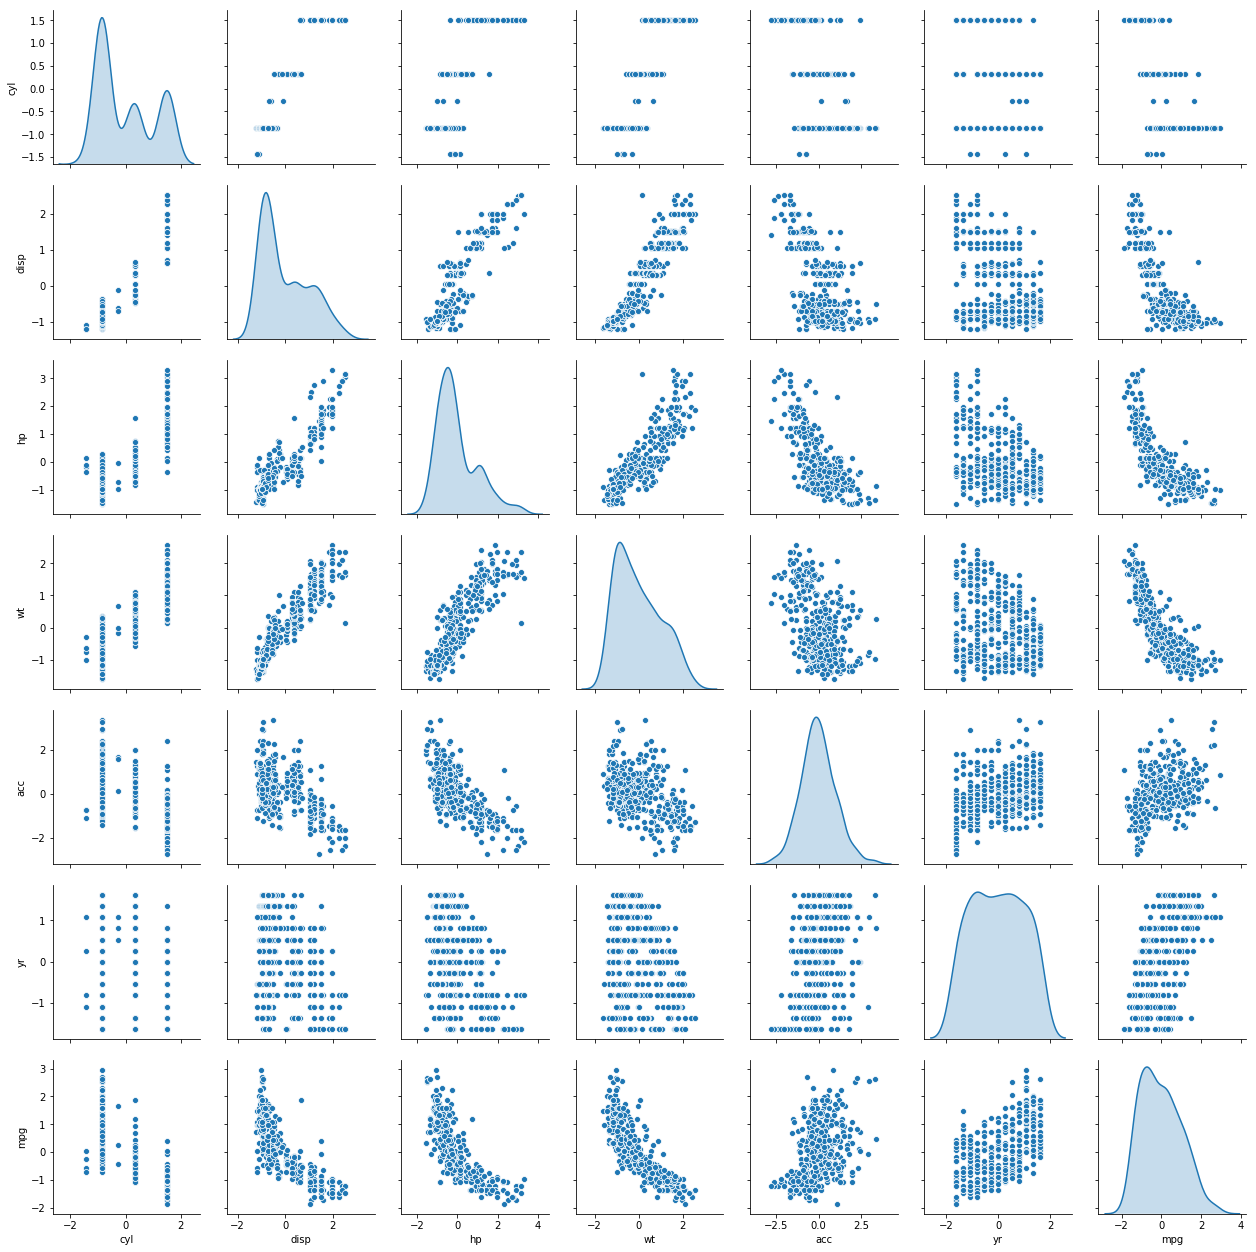

In [37]:
#Let us check for pair plots
sns.pairplot(cars_mpg_df,diag_kind='kde')

# 3. Use K Means or Hierarchical clustering to find out the optimal number of clusters in the data. Identify and separate the clusters (10 points)


In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

cluster_range = range( 2, 6)   # expect 3 to four clusters from the pair panel visual inspection hence restricting from 2 to 6
cluster_errors = []
for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 5)
  clusters.fit(cars_mpg_df)
  labels = clusters.labels_
  centroids = clusters.cluster_centers_
  cluster_errors.append( clusters.inertia_ )
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors } )
clusters_df[0:15]

,num_clusters,cluster_errors
0,2,1760.201819
1,3,1164.728314
2,4,738.392328
3,5,676.064003


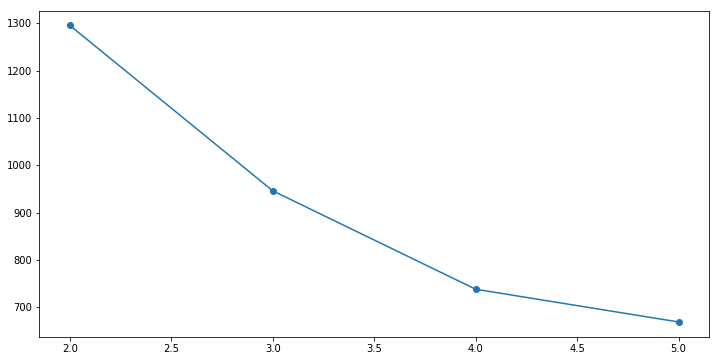

In [39]:
# Elbow plot

plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

Based on the above elbow graph observation , There can be 4 cluster

For n_clusters = 3 The average silhouette_score is : 0.4182811189958267


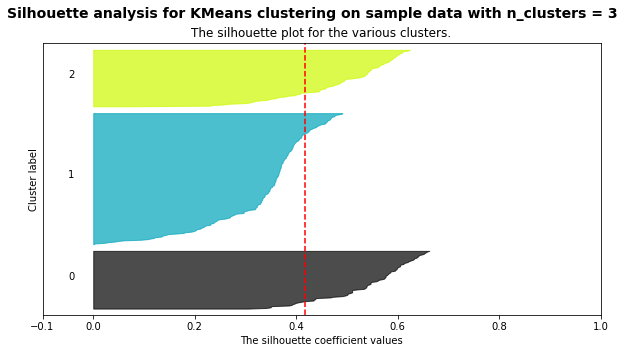

For n_clusters = 4 The average silhouette_score is : 0.4829783284757513


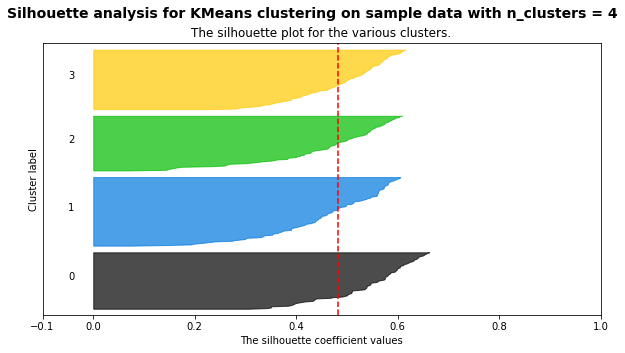

In [60]:
# From the elbow plot looks like number of cluster = 4
# Lets check the Shilhoute coefficient for number of clusters = 3 and 4
range_n_clusters = [3, 4]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1) = plt.subplots(1)
    fig.set_size_inches(10, 5)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(cars_mpg_df) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(cars_mpg_df)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(cars_mpg_df, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(cars_mpg_df, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    #colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    #ax2.scatter(car_mpg[:, 0], car_mpg[:, 1], marker='.', s=30, lw=0, alpha=0.7,
    #            c=colors)

    # Labeling the clusters
    #centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
   # ax2.scatter(centers[:, 0], centers[:, 1],
   #             marker='o', c="white", alpha=1, s=200)

    #for i, c in enumerate(centers):
    #    ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1, s=50)

    #ax2.set_title("The visualization of the clustered data.")
    #ax2.set_xlabel("Feature space for the 1st feature")
    #ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

    plt.show()

In [66]:
kmeans= KMeans(n_clusters=4,random_state=10)
prediction = kmeans.fit_predict(cars_mpg_df_z)


In [67]:
cars_mpg_df_z["GROUP"] = prediction 
cars_mpg_df_z.head()

,cyl,disp,hp,wt,acc,yr,mpg,GROUP
0,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426,-0.706439,2
1,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426,-1.090751,2
2,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426,-0.706439,2
3,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426,-0.962647,2
4,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426,-0.834543,2


/Users/kumanish/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
/Users/kumanish/anaconda3/lib/python3.7/site-packages/statsmodels/nonparametric/kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
/Users/kumanish/anaconda3/lib/python3.7/site-packages/statsmodels/nonparametric/kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
/Users/kumanish/anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, *

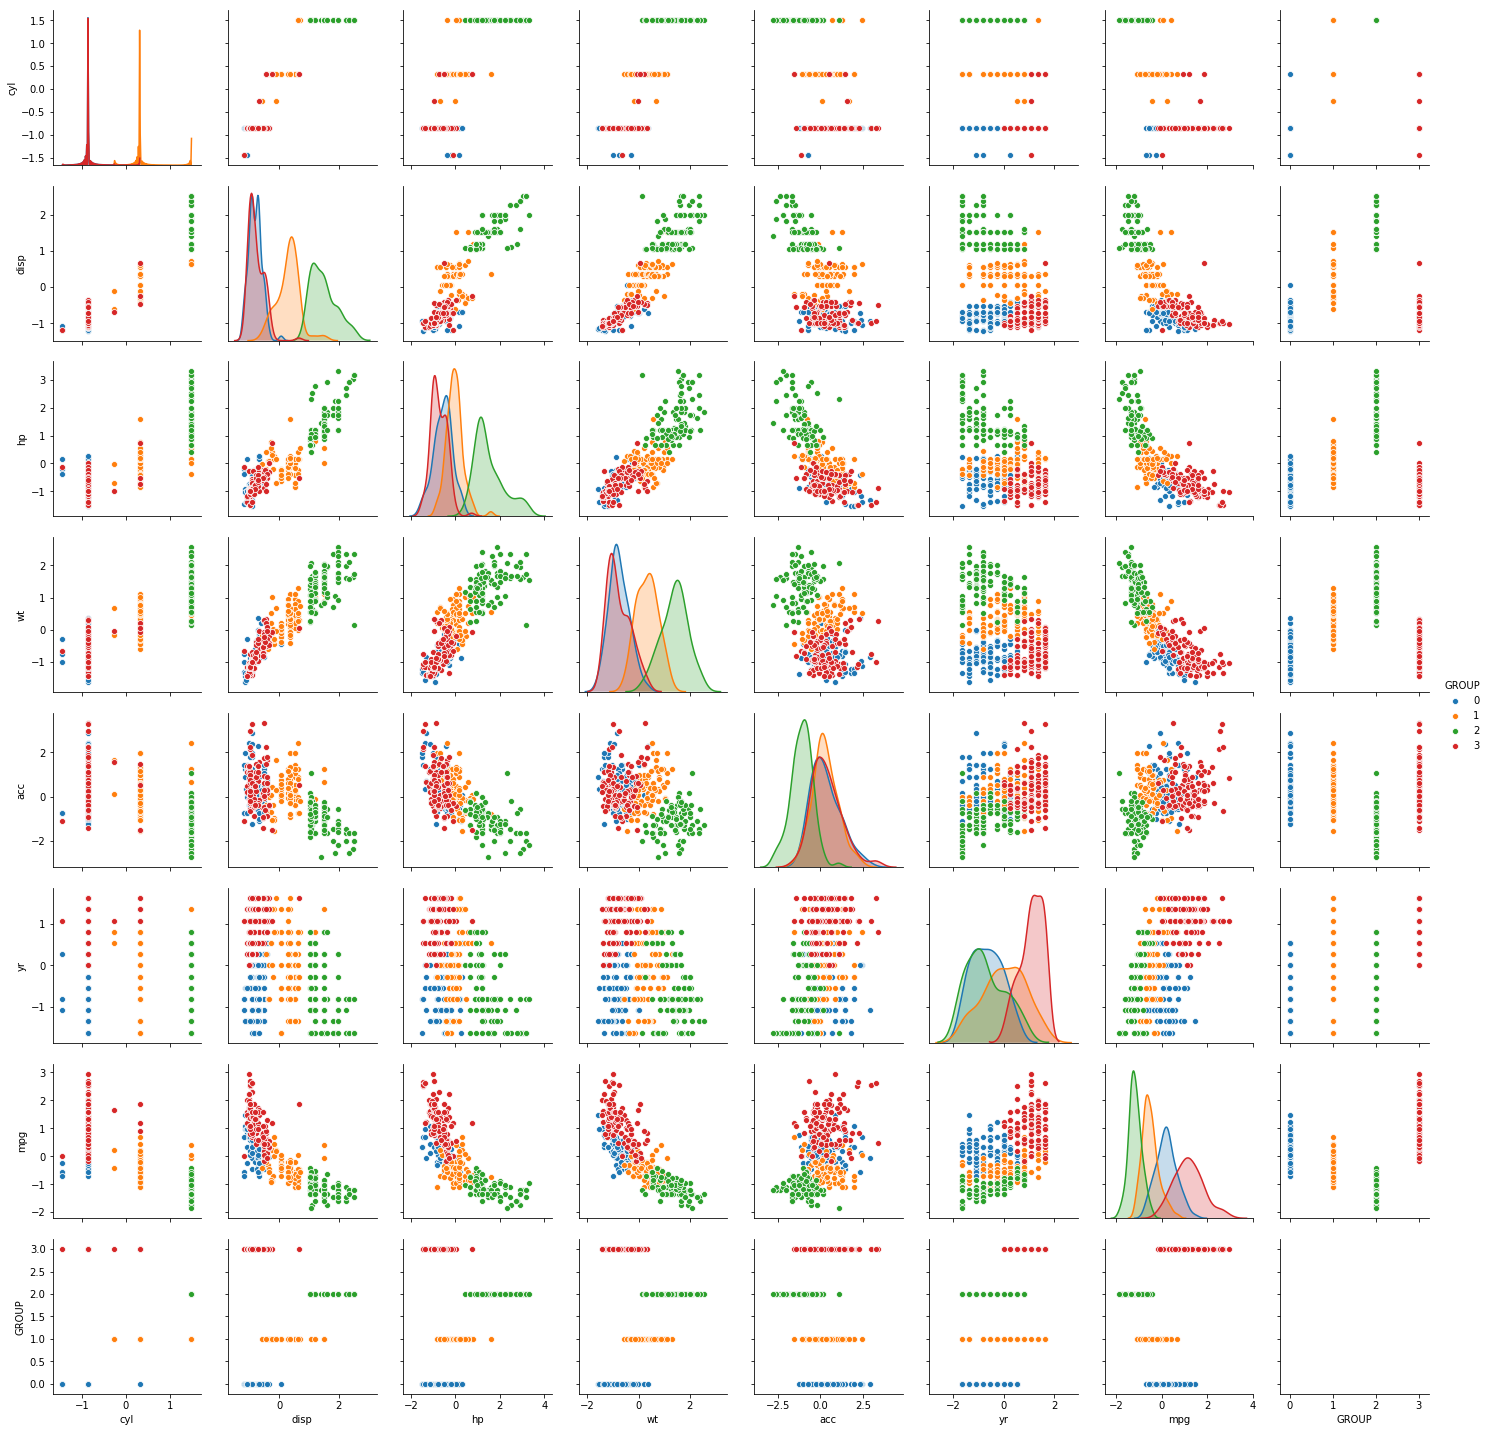

In [68]:
sns.pairplot(cars_mpg_df_z,diag_kind='kde', hue='GROUP') 

In [69]:
cars_mpg_df_z.groupby(['GROUP']).count()['mpg']

GROUP
0     99
1     91
2     94
3    114
Name: mpg, dtype: int64

# 4. Use linear regression model on different clusters separately and print the coefficients of the models individually (10 points)

In [44]:
cars_mpg_df.groupby(["GROUP"]).count()

,cyl,disp,hp,wt,acc,yr,mpg
GROUP,,,,,,,
0,99,99,99,99,99,99,99
1,94,94,94,94,94,94,94
2,114,114,114,114,114,114,114
3,91,91,91,91,91,91,91


In [76]:
# Copy all the predictor variables into X dataframe. Since 'GROUP' is dependent variable drop it
X = cars_mpg_df.drop('GROUP', axis=1)

# Copy the 'GROUP' column alone into the y dataframe. This is the dependent variable
y = cars_mpg_df[['GROUP']]


In [77]:
regression_model = LinearRegression()
#regression_model.fit(X, y)

In [78]:
#regression_model.coef_

In [74]:
#mpg_df1 = mpg_df[mpg_df['GROUP']==0]
#mpg_df2 = mpg_df[mpg_df['GROUP']==1]
#mpg_df3 = mpg_df[mpg_df['GROUP']==2]
#mpg_df4 = mpg_df[mpg_df['GROUP']==3]


In [79]:
Group_range = range(0,4)
cluster_ModelCoef = []
#n=0
for n in Group_range:
    # Copy all the predictor variables into X dataframe. Since 'GROUP' is dependent variable drop it
    mpg_df_copy = cars_mpg_df[cars_mpg_df['GROUP']==n]
    X = mpg_df_copy.drop('GROUP', axis=1)
    y = mpg_df_copy[['GROUP']]
    regression_model.fit(X, y)
    #cluster_ModelCoef_DF1 = cluster_ModelCoef_DF.append(pd.DataFrame(regression_model.coef_, columns = ['cyl', 'disp', 'hp', 'wt', 'acc', 'yr', 'mpg'] ))
    print('Group :' , n )
    DF = pd.DataFrame(regression_model.coef_, columns = ['cyl', 'disp', 'hp', 'wt', 'acc', 'yr', 'mpg'] )
    print(DF)
    DF['GROUP'] = n
    n=n+1

Group : 0
   cyl  disp   hp   wt  acc   yr  mpg
0  0.0   0.0  0.0  0.0  0.0  0.0  0.0
Group : 1
   cyl  disp   hp   wt  acc   yr  mpg
0  0.0   0.0  0.0  0.0  0.0  0.0  0.0
Group : 2
   cyl  disp   hp   wt  acc   yr  mpg
0  0.0   0.0  0.0  0.0  0.0  0.0  0.0
Group : 3
   cyl  disp   hp   wt  acc   yr  mpg
0  0.0   0.0  0.0  0.0  0.0  0.0  0.0
